# Mobile Money Fraud Detection — Rwanda (Updated v2)
## Business Rules Integrated:
1. **Amount Spike** — user sends much more than their typical range → Face required
2. **PIN Failure (3rd attempt)** — 2 wrong PINs → Face required on 3rd try
3. **Balance Abuse (3rd time)** — tried to send > balance 3+ times → Hard block, no face

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time, warnings, json, os
import joblib
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay, f1_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import lightgbm as lgb

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
print("All libraries loaded.")

All libraries loaded.


## Phase 1 — Generate Synthetic Dataset with Business Rules

In [2]:
np.random.seed(42)
N = 200_000

type_choices      = np.random.choice([0,1,2,3,4], size=N, p=[0.25,0.35,0.05,0.20,0.15])
old_balance_orig  = np.random.exponential(50000, N)
old_balance_dest  = np.random.exponential(30000, N)
user_typical_max  = np.random.uniform(5000, 10000, N)   # each user's normal ceiling

# Amounts: 95% normal, 5% large spike
amount = np.where(
    np.random.rand(N) < 0.05,
    np.random.uniform(20000, 300000, N),
    np.random.uniform(100, user_typical_max)
)
amount           = np.clip(amount, 1, None)
new_balance_orig = np.maximum(0, old_balance_orig - amount)
new_balance_dest = old_balance_dest + amount * np.random.uniform(0.95, 1.05, N)
step             = np.random.randint(1, 744, N)

# ── RULE FEATURES ────────────────────────────────────────────────────────────
# Rule 1: amount spike (> 5x the user's typical max)
amount_vs_typical   = amount / (user_typical_max + 1)
is_amount_spike     = (amount_vs_typical > 5).astype(int)

# Rule 2: PIN failure simulation
pin_fail_count      = np.where(np.random.rand(N) < 0.10,
                                np.random.choice([2,3], N, p=[0.7,0.3]), 0)
pin_near_lockout    = (pin_fail_count >= 2).astype(int)

# Rule 3: Balance abuse
exceeds_balance     = (amount > old_balance_orig).astype(int)
balance_abuse_count = np.where(np.random.rand(N) < 0.05,
                                np.random.choice([2,3], N, p=[0.6,0.4]), 0)
hard_block_signal   = ((exceeds_balance == 1) & (balance_abuse_count >= 3)).astype(int)

# ── FRAUD LABELS ─────────────────────────────────────────────────────────────
base_fraud  = (((type_choices==4)|(type_choices==1)) &
               (new_balance_orig < old_balance_orig*0.02) &
               (amount > old_balance_orig*0.8)).astype(int)
spike_fraud = ((is_amount_spike==1) & (np.random.rand(N)<0.4)).astype(int)
pin_fraud   = ((pin_near_lockout==1) & (np.random.rand(N)<0.35)).astype(int)
is_fraud    = np.clip(base_fraud+spike_fraud+pin_fraud+hard_block_signal, 0, 1)
# tiny noise
noise = np.random.rand(N) < 0.002
is_fraud[noise] = 1 - is_fraud[noise]

df = pd.DataFrame({
    "step": step, "type": type_choices, "amount": amount,
    "oldbalanceOrg": old_balance_orig, "newbalanceOrig": new_balance_orig,
    "oldbalanceDest": old_balance_dest, "newbalanceDest": new_balance_dest,
    "user_typical_max": user_typical_max,
    "pin_fail_count": pin_fail_count,
    "balance_abuse_count": balance_abuse_count,
    "isFraud": is_fraud
})

print(f"Dataset   : {df.shape}")
print(f"Fraud rate: {df['isFraud'].mean()*100:.2f}%  ({df['isFraud'].sum():,} frauds)")

Dataset   : (200000, 11)
Fraud rate: 10.14%  (20,287 frauds)


## Phase 2 — Feature Engineering

In [3]:
for col in ["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]:
    df[f"log_{col}"] = np.log1p(df[col])

df["orig_balance_drop"]      = df["log_oldbalanceOrg"]  - df["log_newbalanceOrig"]
df["dest_balance_gain"]      = df["log_newbalanceDest"] - df["log_oldbalanceDest"]
df["balance_mismatch"]       = df["orig_balance_drop"]  - df["dest_balance_gain"]
df["sender_zero_after"]      = (df["newbalanceOrig"] == 0).astype(int)
df["dest_zero_before"]       = (df["oldbalanceDest"] == 0).astype(int)
df["amount_to_bal_ratio"]    = df["amount"] / (df["oldbalanceOrg"] + 1)
df["type_encoded"]           = df["type"]
df["hour_of_day"]            = df["step"] % 24
q95 = df["amount"].quantile(0.95)
df["is_high_amount"]         = (df["amount"] > q95).astype(int)

# ── NEW: Business-rule features ───────────────────────────────────────────────
df["amount_vs_typical"]      = df["amount"] / (df["user_typical_max"] + 1)
df["is_amount_spike"]        = (df["amount_vs_typical"] > 5).astype(int)
df["pin_near_lockout"]       = (df["pin_fail_count"] >= 2).astype(int)
df["amount_exceeds_balance"] = (df["amount"] > df["oldbalanceOrg"]).astype(int)
df["hard_block_signal"]      = ((df["amount_exceeds_balance"]==1) &
                                 (df["balance_abuse_count"]>=3)).astype(int)
df["excess_ratio"]           = np.maximum(0, df["amount"]-df["oldbalanceOrg"]) / (df["oldbalanceOrg"]+1)

FEATURES = [
    "log_amount","log_oldbalanceOrg","log_newbalanceOrig",
    "log_oldbalanceDest","log_newbalanceDest",
    "orig_balance_drop","dest_balance_gain","balance_mismatch",
    "sender_zero_after","dest_zero_before","amount_to_bal_ratio",
    "type_encoded","hour_of_day","is_high_amount",
    # Rule 1 — amount spike
    "amount_vs_typical","is_amount_spike",
    # Rule 2 — PIN failures
    "pin_near_lockout",
    # Rule 3 — balance abuse
    "amount_exceeds_balance","hard_block_signal","excess_ratio",
]
print(f"Total features: {len(FEATURES)}")
print("Features:", FEATURES)

Total features: 20
Features: ['log_amount', 'log_oldbalanceOrg', 'log_newbalanceOrig', 'log_oldbalanceDest', 'log_newbalanceDest', 'orig_balance_drop', 'dest_balance_gain', 'balance_mismatch', 'sender_zero_after', 'dest_zero_before', 'amount_to_bal_ratio', 'type_encoded', 'hour_of_day', 'is_high_amount', 'amount_vs_typical', 'is_amount_spike', 'pin_near_lockout', 'amount_exceeds_balance', 'hard_block_signal', 'excess_ratio']


## Phase 3 — Split, Scale & SMOTE

In [4]:
X = df[FEATURES]
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)
print(f"Train: {X_train_sm.shape[0]:,} samples after SMOTE")
print(f"Test : {X_test.shape[0]:,} samples")

Train: 287,540 samples after SMOTE
Test : 40,000 samples


## Phase 4 — Train XGBoost & LightGBM

In [5]:
models = {
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        eval_metric="logloss", random_state=42, n_jobs=-1,
        use_label_encoder=False),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=42, n_jobs=-1, verbose=-1),
}

results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    t0 = time.time()
    model.fit(X_train_sm, y_train_sm)
    elapsed  = time.time() - t0
    y_pred   = model.predict(X_test_scaled)
    y_proba  = model.predict_proba(X_test_scaled)[:, 1]
    auc      = roc_auc_score(y_test, y_proba)
    rep      = classification_report(y_test, y_pred,
                                     target_names=["Legit","Fraud"],
                                     output_dict=True)
    fraud_f1 = rep["Fraud"]["f1-score"]
    results[name] = {"model": model, "auc": auc, "fraud_f1": fraud_f1,
                     "report": rep, "y_proba": y_proba}
    print(f"  {elapsed:.1f}s | Fraud F1: {fraud_f1:.4f} | ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Legit","Fraud"]))

best_name = max(results, key=lambda k: results[k]["fraud_f1"])
best      = results[best_name]
print(f"\n>>> WINNER: {best_name}  (Fraud F1={best['fraud_f1']:.4f})")


Training XGBoost...
  2.2s | Fraud F1: 0.7223 | ROC-AUC: 0.9728
              precision    recall  f1-score   support

       Legit       0.99      0.93      0.96     35943
       Fraud       0.59      0.92      0.72      4057

    accuracy                           0.93     40000
   macro avg       0.79      0.92      0.84     40000
weighted avg       0.95      0.93      0.93     40000


Training LightGBM...
  2.0s | Fraud F1: 0.7189 | ROC-AUC: 0.9729
              precision    recall  f1-score   support

       Legit       0.99      0.94      0.96     35943
       Fraud       0.61      0.88      0.72      4057

    accuracy                           0.93     40000
   macro avg       0.80      0.91      0.84     40000
weighted avg       0.95      0.93      0.94     40000


>>> WINNER: XGBoost  (Fraud F1=0.7223)


## Phase 5 — Threshold Tuning

Optimal threshold: 0.38
Best Fraud F1    : 0.7236


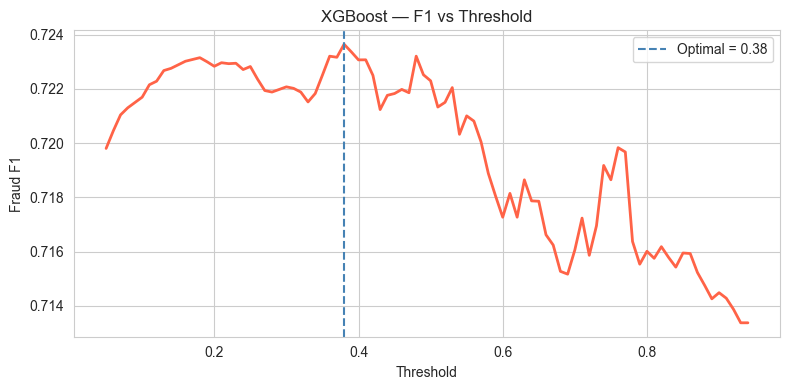

In [6]:
y_proba_best = best["y_proba"]
thresh_range = np.arange(0.05, 0.95, 0.01)
f1_list      = [f1_score(y_test, (y_proba_best>=t).astype(int), zero_division=0)
                for t in thresh_range]

optimal_threshold = float(thresh_range[np.argmax(f1_list)])
print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"Best Fraud F1    : {max(f1_list):.4f}")

plt.figure(figsize=(8,4))
plt.plot(thresh_range, f1_list, color="tomato", lw=2)
plt.axvline(optimal_threshold, color="steelblue", linestyle="--", lw=1.5,
            label=f"Optimal = {optimal_threshold:.2f}")
plt.xlabel("Threshold"); plt.ylabel("Fraud F1")
plt.title(f"{best_name} — F1 vs Threshold")
plt.legend(); plt.tight_layout(); plt.show()

## Phase 6 — Feature Importance (Business Rule Signals)

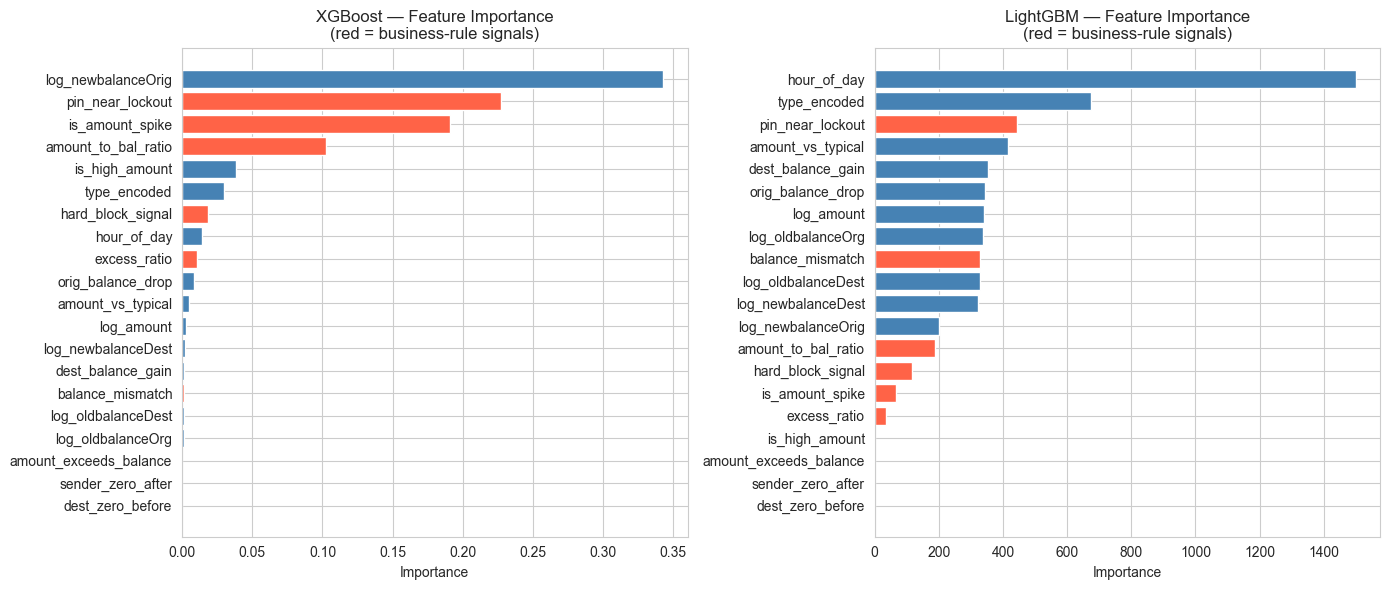

Red bars = the 3 new business-rule features.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, res) in zip(axes, results.items()):
    imps    = res["model"].feature_importances_
    feat_df = pd.DataFrame({"feature": FEATURES, "importance": imps})
    feat_df = feat_df.sort_values("importance", ascending=True)
    colors  = [
        "tomato" if any(k in f for k in
                        ["spike","pin","exceed","block","excess","zero","ratio","mismatch"])
        else "steelblue"
        for f in feat_df["feature"]
    ]
    ax.barh(feat_df["feature"], feat_df["importance"], color=colors)
    ax.set_title(f"{name} — Feature Importance\n(red = business-rule signals)")
    ax.set_xlabel("Importance")
plt.tight_layout(); plt.show()
print("Red bars = the 3 new business-rule features.")

## Phase 7 — Business Rules Demo
> Shows how the 3 rules trigger face-verify or hard-block

In [8]:
def evaluate_transaction(
    amount, balance, user_typical_max,
    pin_fail_count, balance_abuse_count,
    model, scaler, threshold, features
):
    """
    Returns action: ALLOW | REQUIRE_FACE | HARD_BLOCK
    Priority: HARD_BLOCK > REQUIRE_FACE > ML score
    """
    # Rule 3a: amount exceeds balance → HARD BLOCK always
    if amount > balance:
        if balance_abuse_count >= 3:
            return {"action": "HARD_BLOCK", "reason": "Rule3: exceeded balance 3+ times",
                    "ml_score": None}
        return {"action": "HARD_BLOCK", "reason": "Rule3: impossible tx (amount > balance)",
                "ml_score": None}

    # Rule 2: 3rd PIN attempt
    if pin_fail_count >= 2:
        action = "REQUIRE_FACE"
        reason = "Rule2: 2 wrong PINs — face required on 3rd attempt"
    # Rule 1: amount spike
    elif amount > user_typical_max * 5:
        action = "REQUIRE_FACE"
        reason = f"Rule1: amount {amount:,.0f} >> typical max {user_typical_max:,.0f}"
    else:
        action = None
        reason = "No rule trigger"

    # ML score
    row = {
        "log_amount":           np.log1p(amount),
        "log_oldbalanceOrg":    np.log1p(balance),
        "log_newbalanceOrig":   np.log1p(max(0, balance - amount)),
        "log_oldbalanceDest":   0, "log_newbalanceDest": np.log1p(amount),
        "orig_balance_drop":    np.log1p(balance) - np.log1p(max(0, balance-amount)),
        "dest_balance_gain":    np.log1p(amount),
        "balance_mismatch":     0,
        "sender_zero_after":    int(balance - amount <= 0),
        "dest_zero_before":     0,
        "amount_to_bal_ratio":  amount / (balance + 1),
        "type_encoded":         4,   # TRANSFER
        "hour_of_day":          12,
        "is_high_amount":       0,
        "amount_vs_typical":    amount / (user_typical_max + 1),
        "is_amount_spike":      int(amount > user_typical_max * 5),
        "pin_near_lockout":     int(pin_fail_count >= 2),
        "amount_exceeds_balance": 0,
        "hard_block_signal":    0,
        "excess_ratio":         0,
    }
    vec   = np.array([[row[f] for f in features]])
    vec_s = scaler.transform(vec)
    score = model.predict_proba(vec_s)[0][1]

    if action is None:
        if score >= threshold:
            action = "REQUIRE_FACE"
            reason = f"ML score {score:.3f} >= threshold {threshold}"
        else:
            action = "ALLOW"

    return {"action": action, "reason": reason, "ml_score": round(float(score), 4)}

# ─── Test scenarios ───────────────────────────────────────────────────────────
balance   = 50_000  # user's balance
typical   = 5_000   # user's normal max per day

scenarios = [
    ("Normal send 2k",        2_000,  balance, typical, 0, 0),
    ("Normal send 5k",        5_000,  balance, typical, 0, 0),
    ("Spike: 100k (>> 5k)",  100_000, balance, typical, 0, 0),
    ("Wrong PIN x2 (3rd)",    3_000,  balance, typical, 2, 0),
    ("Over balance (1st)",   55_000,  balance, typical, 0, 0),
    ("Over balance (3rd!)",  55_000,  balance, typical, 0, 3),
]

model_obj = best["model"]
print(f"{'Scenario':<30} {'Amount':>10} {'Action':<15} {'Reason'}")
print("="*90)
for label, amt, bal, typ, pins, bal_abuse in scenarios:
    res = evaluate_transaction(amt, bal, typ, pins, bal_abuse,
                               model_obj, scaler, optimal_threshold, FEATURES)
    icon = {"ALLOW":"✅","REQUIRE_FACE":"🔐","HARD_BLOCK":"🚨"}[res["action"]]
    print(f"{icon} {label:<28} {amt:>10,.0f}   {res['action']:<15} {res['reason']}")

Scenario                           Amount Action          Reason
✅ Normal send 2k                    2,000   ALLOW           No rule trigger
✅ Normal send 5k                    5,000   ALLOW           No rule trigger
🚨 Spike: 100k (>> 5k)             100,000   HARD_BLOCK      Rule3: impossible tx (amount > balance)
🔐 Wrong PIN x2 (3rd)                3,000   REQUIRE_FACE    Rule2: 2 wrong PINs — face required on 3rd attempt
🚨 Over balance (1st)               55,000   HARD_BLOCK      Rule3: impossible tx (amount > balance)
🚨 Over balance (3rd!)              55,000   HARD_BLOCK      Rule3: exceeded balance 3+ times


## Phase 8 — Save Best Model & Config

In [9]:
best_model = best["model"]

joblib.dump(best_model, "fraud_best_model.pkl")
joblib.dump(scaler,     "fraud_scaler.pkl")

config = {
    "best_model": best_name,
    "threshold":  round(optimal_threshold, 2),
    "features":   FEATURES,
    "n_features": len(FEATURES),
    "fraud_f1":   round(best["fraud_f1"], 4),
    "roc_auc":    round(best["auc"], 4),
    "fraud_logic": {
        "rule1_amount_spike":   "amount > 5x user_typical_max → REQUIRE_FACE",
        "rule2_pin_failures":   "pin_fail_count >= 2 (3rd attempt) → REQUIRE_FACE",
        "rule3_balance_abuse":  "amount > balance → HARD_BLOCK (impossible tx); if 3rd time → permanent block",
        "face_verify_triggers": ["is_amount_spike=1", "pin_near_lockout=1"],
        "hard_block_no_face":   ["amount > balance (any time)", "hard_block_signal=1 (3rd time)"]
    }
}

with open("fraud_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved: fraud_best_model.pkl")
print("Saved: fraud_scaler.pkl")
print("Saved: fraud_config.json")
print()
print(json.dumps(config, indent=2))

Saved: fraud_best_model.pkl
Saved: fraud_scaler.pkl
Saved: fraud_config.json

{
  "best_model": "XGBoost",
  "threshold": 0.38,
  "features": [
    "log_amount",
    "log_oldbalanceOrg",
    "log_newbalanceOrig",
    "log_oldbalanceDest",
    "log_newbalanceDest",
    "orig_balance_drop",
    "dest_balance_gain",
    "balance_mismatch",
    "sender_zero_after",
    "dest_zero_before",
    "amount_to_bal_ratio",
    "type_encoded",
    "hour_of_day",
    "is_high_amount",
    "amount_vs_typical",
    "is_amount_spike",
    "pin_near_lockout",
    "amount_exceeds_balance",
    "hard_block_signal",
    "excess_ratio"
  ],
  "n_features": 20,
  "fraud_f1": 0.7223,
  "roc_auc": 0.9728,
  "fraud_logic": {
    "rule1_amount_spike": "amount > 5x user_typical_max \u2192 REQUIRE_FACE",
    "rule2_pin_failures": "pin_fail_count >= 2 (3rd attempt) \u2192 REQUIRE_FACE",
    "rule3_balance_abuse": "amount > balance \u2192 HARD_BLOCK (impossible tx); if 3rd time \u2192 permanent block",
    "face_ver